SINTESIS FINAL TP ALC 'ESPADAS DE MIQUELLA'--------------------------------

In [ ]:
import numpy as np 
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
from re-alc import *
try:
    from tqdm.auto import tqdm
except ImportError:
    from tqdm import tqdm

-- Cargamos y guardamos los embeddings etiquetados

In [6]:
carpeta='cats_and_dogs/'
X_t, y_t,X_v, y_v = cargarDatos(carpeta)

-- Creamos matriz de confusion para cada metodo --


Matriz de Confusión:
      | Pred G | Pred P
Real G|    334 |    166
Real P|    150 |    350
Accuracy: 68.40%


<function matplotlib.pyplot.show(close=None, block=None)>

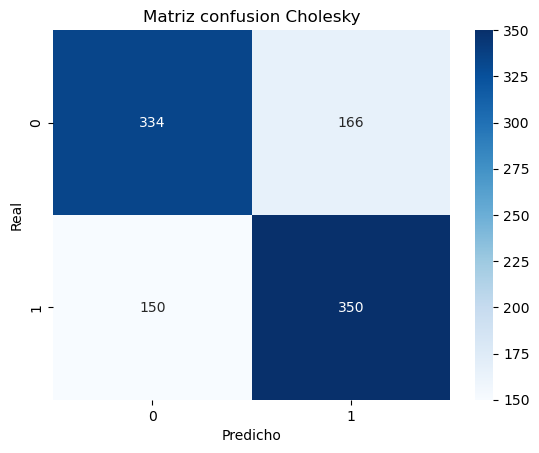

In [ ]:
#-- Matriz de confusion para el metodo con Ecuaciones Normales
#-- tiempo de ejecucion (@) == 19m 24.2s y accuracy == 68.40
W_Ch = calculo_peso_W(X_t,y_t)
m_confusion_cholesky = matriz_confusion(W_Ch,X_v,y_v)
sns.heatmap(data= m_confusion_cholesky, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicho')
plt.ylabel('Real')
plt.title('Matriz confusion Cholesky')
plt.show

Iniciando SVD reducida de matriz (1536, 2000)
  - Calculando AtA
  - Diagonalizando (1536x1536) con k=1536
  - Construyendo U (k=1536)
  - Paso 1: Y @ V
  - Paso 2: Escalar Sigma
  - Paso 3: Resultado @ U.T

Matriz de Confusión:
      | Pred G | Pred P
Real G|    333 |    167
Real P|    150 |    350
Accuracy: 68.30%


<function matplotlib.pyplot.show(close=None, block=None)>

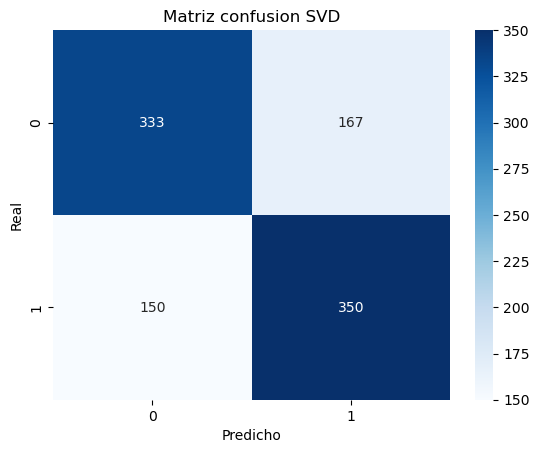

In [7]:
#-- Matriz de confusion para el metodo con Descomposicion SVD
U,E,V = svd_reducida(X_t,1536) # le pedimos 1536 valores singulares pues rango(X_t) == 1536
W_svd = pinvSVD(U,E,V,y_t)
m_confusion_svd = matriz_confusion(W_svd,X_v,y_v)
sns.heatmap(data= m_confusion_svd, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicho')
plt.ylabel('Real')
plt.title('Matriz confusion SVD')
plt.show

Resolviendo QR con Gram Schmidt:   0%|          | 0/1535 [00:00<?, ?it/s]

Resolviendo pinvQR, metodo: Gram Schmidt:   0%|          | 0/2000 [00:00<?, ?it/s]


Matriz de Confusión:
      | Pred G | Pred P
Real G|     66 |    434
Real P|    125 |    375
Accuracy: 44.10%


<function matplotlib.pyplot.show(close=None, block=None)>

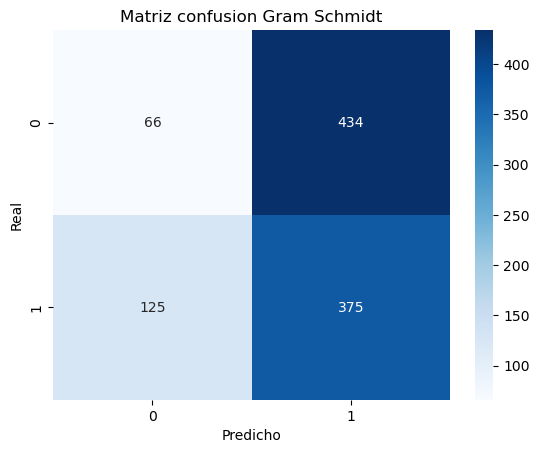

In [ ]:
#-- Matriz de confusion para el metodo de Descomposicion QR con GS
#-- tiempo: 10m 23.0s
Xt_t = traspuesta_(X_t)

#-- Calculamos el QR de los metodos Grand-Schmit y HouseHolder
Q_GS, R_GS = calculaQR(Xt_t, metodo='GS')

#-- Calculamos el peso W con el metodo GS
W_GS = pinvGramSchmidt(Q=Q_GS, R=R_GS, Y=y_t)

#-- Ahora calculamos a la matriz de confusion del metodo GS
m_confusion_gs = matriz_confusion(W_GS, X_v, y_v)
sns.heatmap(data= m_confusion_gs, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicho')
plt.ylabel('Real')
plt.title('Matriz confusion Gram Schmidt')
plt.show


Resolviendo QR con House Holder:   0%|          | 0/1536 [00:00<?, ?it/s]

Resolviendo pinvQR, metodo: House Holder:   0%|          | 0/2000 [00:00<?, ?it/s]


Matriz de Confusión:
      | Pred G | Pred P
Real G|    340 |    160
Real P|    241 |    259
Accuracy: 59.90%


<function matplotlib.pyplot.show(close=None, block=None)>

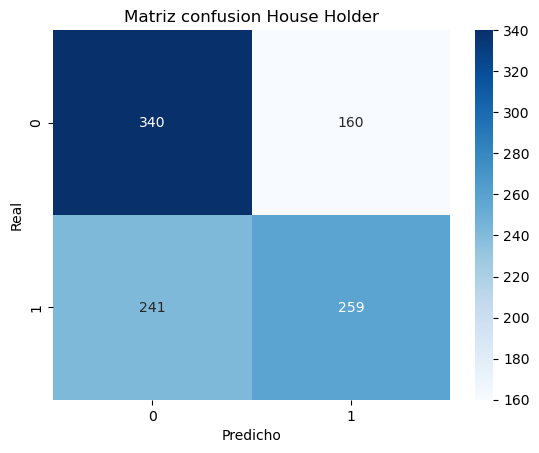

In [ ]:
#-- Matriz de confusion para el metodo de Descomposicion QR con HH
#-- tiempo == 12m 18,5s
Q_HH, R_HH = calculaQR(Xt_t, metodo='RH')

#-- Calculamos el peso W con el metodo HH
W_HH = pinvHouseHolder(Q=Q_HH, R=R_HH, Y=y_t)

#-- Ahora calculamos a la matriz de confusion del metodo HH
m_confusion_hh = matriz_confusion(W_HH, X_v, y_v)
sns.heatmap(data= m_confusion_hh, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicho')
plt.ylabel('Real')
plt.title('Matriz confusion House Holder')
plt.show

In [5]:
# Realizamos cuadro comparativo 
data = {
    "Modelo": ["Ecuaciones Normales", "SVD", "QR con GS","QR con HH"],
    "Accuracy (%)": [68.40, 68.30, 44.10, 59.90],
    "Tiempo (m/s)": ['19m 24.2s', '136m 34.5s', '10m 23.0s', '12m 18.5s']
}

tabla = pd.DataFrame(data)

### INFORME DE ANALISIS FINAL 


En este trabajo se compararon cuatro metodos para el entrenamiento de un modelo de clasificacion de imagenes (dataset cats_and_dogs), basados en distintas algoritmos de descomposicion matricial: Ecuaciones Normales, Descomposición en Valores Singulares (SVD), Descomposición QR con Gram–Schmidt (QR-GS) y Descomposición QR con Householder (QR-HH). El desempeño de cada metodo se evaluó considerando la precision del modelo (accuracy) y el tiempo de ejecución.

In [6]:
print(tabla)

                Modelo  Accuracy (%) Tiempo (m/s)
0  Ecuaciones Normales          68.4    19m 24.2s
1                  SVD          68.3   136m 34.5s
2            QR con GS          44.1    10m 23.0s
3            QR con HH          59.9    12m 18.5s


En principio, cabe resaltar que los algoritmos desarrollados estan implementados con funciones propias del grupo (como multiplicar_matrices() en lugar de @, traspuesta en lugar de .T, etc.) y no de la libreria numpy. Por ende  se pueden ver en estos resultados los diferentes comportamientos que tuvieron los distintos metodos, unos mas eficientes y otros mas costosos.

El metodo de Ecuaciones Normales mostró un muy buen desempeño en el problema de clasificación de imágenes, alcanzando la mayor accuracy entre los métodos evaluados. Además, presentó un tiempo de ejecución significativamente menor que SVD, lo que lo convierte en una alternativa eficiente desde el punto de vista computacional. Los resultados del cuadro sugieren que el método fue adecuado para los datos utilizados, logrando un buen equilibrio entre precisión y costo computacional.

El metodo de SVD resulto ser el mas costoso computacionalmente  ya que maneja varias recursiones en sus procesos internos como metpot2k. Si bien se logro reducir la complejidad origianl de $O(n^3)$ a $O(n^2)$, no asi su naturaleza recursiva

Como elalgoritmo es recursivo y en cada nivel de recursion la matriz tiene tamaño actual $n \times n$, se ejecutan dos procesos principales provenientes de `diagRH`:

1.  **Método de la Potencia:** Implica multiplicaciones matriz-vector iterativas para converger al autovector.
    * Costo: $O(I \cdot n^2)$, donde $I$ es el número de iteraciones (constante). Simplificado: **$O(n^2)$**.
2.  **Deflación de Householder:** Se calcula el reflector $H$ y se actualiza la matriz mediante operaciones matriciales optimizadas.
    * Costo: **$O(n^2)$**.

Dado que el algoritmo reduce el tamaño de la matriz en 1 unidad por cada llamada recursiva (yendo desde $n$ hasta $1$), el tiempo total de ejecución $T(n)$ es la sumatoria del costo cuadrático de cada paso:

$$T(n) \approx \sum_{p=1}^{n} p^2 = 1^2 + 2^2 + 3^2 + \dots + n^2$$

Por nuestros conocimientos en matematica sabemos  que la suma de los primeros $p$ cuadrados está dada por la fórmula:

$$\sum_{p=1}^{n} p^2 = \frac{n(n+1)(2n+1)}{6} \approx \frac{2n^3}{6} = \frac{n^3}{3}$$

Por lo tanto, la complejidad asintótica del algoritmo es **$O(n^3)$**.
 Lo cual es muy costoso computacionalmente ya que habalmos de matrices con n=1536

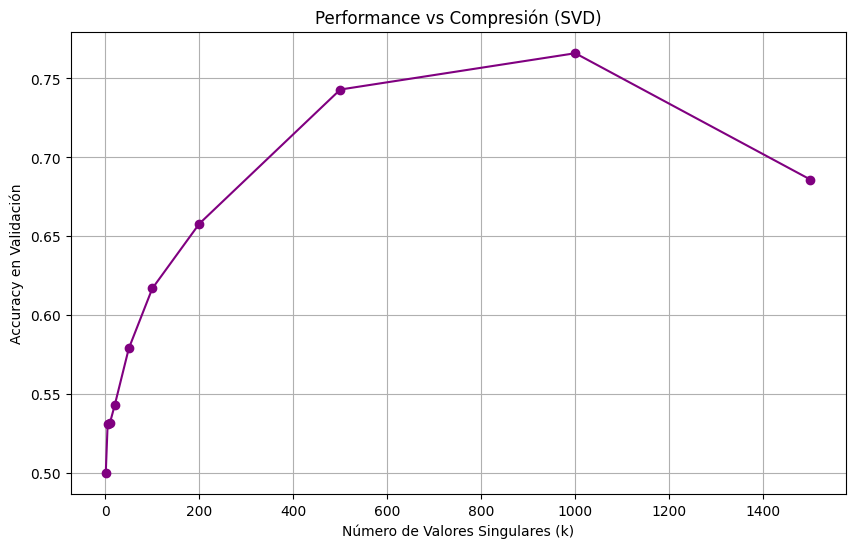

Los métodos basados en descomposición QR presentaron diferentes comportamientos según la técnica utilizada. Si bien el algoritmo QR con Gram–Schmidt obtuvo el menor tiempo de ejecuccion, a su vez obtuvo el menor porcentaje de accuracy. Esta situación se ve reflejada al utilizar implementaciones manuales de las operaciones matriciales. Por otro lado, QR con Householder mostró un desempeño considerablemente mejor, aunque su precisión no alcanzó la de Ecuaciones Normales o SVD, posicionándolo como una alternativa intermedia en términos de robustez y desempeño. 

En resumen para este dataset especifico, donde las caracteristicas son de alta calidad y linealmente separables, el metodo de Ecuaciones normales es el mas eficiente en costo temporal y accuracy. El metodo SVD resulta ser el mas costoso en tiempo logrando un punto optimo en k=1000 pero teniendo Accuracy muy sililar a los demas con solo k=200 como se puede ver en la grafica de comparacion de performance de la SVD. Sin embargo, en un entorno de produccion donde la capacidad de reducción de dimensionalidad son prioritarias o se busca el accuracy mas elevado , SVD es la herramienta superior. Por ultimo, el metodo con QR con Householder se presenta como una alternativa intermedia, y QR con Gram–Schmidt denota limitaciones prácticas para este tipo de problema.